In [1]:
import matplotlib.pyplot as plt
import os
import numpy as np

In [2]:
# get the total energy from the OUTCAR file
def get_total_energy(outcar_file):
    with open(outcar_file, 'r') as f:
        lines = f.readlines()
        for line in lines:
            if 'free  energy   TOTEN' in line:
                energy = float(line.split()[4])
                return energy
    return None

In [3]:
encuts = []
energies = []

subfolders = os.listdir("bachelor-thesis/encut_convergence")
# sort the subfolders by encut value
subfolders.sort(key=lambda x: int(x.split("_")[1]))

for subfolder in subfolders:
    if subfolder.startswith("encut_"):
        encut_value = int(subfolder.split("_")[1])
        energy = get_total_energy(f'bachelor-thesis/encut_convergence/{subfolder}/OUTCAR')
        print(f'ENCUT: {encut_value} eV, Total Energy: {energy} eV')
        if energy is not None:
            encuts.append(encut_value)
            energies.append(energy)

ENCUT: 100 eV, Total Energy: 773.59421545 eV
ENCUT: 200 eV, Total Energy: -99.47746827 eV
ENCUT: 300 eV, Total Energy: -103.35686183 eV
ENCUT: 350 eV, Total Energy: -103.30875589 eV
ENCUT: 400 eV, Total Energy: -103.35888117 eV
ENCUT: 450 eV, Total Energy: -103.36148258 eV
ENCUT: 500 eV, Total Energy: -103.34154901 eV


In [4]:
def check_encut_convergence(encut, energies, n_last=3,
                            tol_meV_per_atom=1.0,
                            n_atoms=1):
    """
    Determine whether ENCUT convergence is achieved.

    Parameters
    ----------
    encut : list or array
        ENCUT values (ascending order recommended)
    energies : list or array
        Total energies corresponding to ENCUT values (eV)
    n_last : int
        Number of last points to check for convergence
    tol_meV_per_atom : float
        Convergence threshold in meV/atom
    n_atoms : int
        Number of atoms in the system

    Returns
    -------
    dict with:
        converged (bool)
        max_delta_meV_per_atom (float)
        max_slope_meV_per_atom (float)
    """

    encut = np.array(encut)
    energies = np.array(energies)

    # convert to energy per atom (meV)
    epa = (energies / n_atoms) * 1000  # eV → meV

    if len(epa) < n_last + 1:
        raise ValueError("Not enough data points for convergence test")

    # take last segment
    e_tail = epa[-n_last:]
    x_tail = encut[-n_last:]

    # max energy fluctuation in tail
    max_delta = np.max(e_tail) - np.min(e_tail)

    # approximate slope in tail (linear fit)
    slope = np.polyfit(x_tail, e_tail, 1)[0]

    # convergence criteria
    converged = (
        max_delta < tol_meV_per_atom and
        abs(slope) < tol_meV_per_atom / (x_tail.max() - x_tail.min())
    )

    return {
        "converged": converged,
        "max_delta_meV_per_atom": max_delta,
        "max_slope_meV_per_atom": slope
    }

In [5]:
check_encut_convergence(encuts, energies, n_atoms=58)

{'converged': np.True_,
 'max_delta_meV_per_atom': np.float64(0.34368224137915604),
 'max_slope_meV_per_atom': np.float64(0.0029883034482803394)}

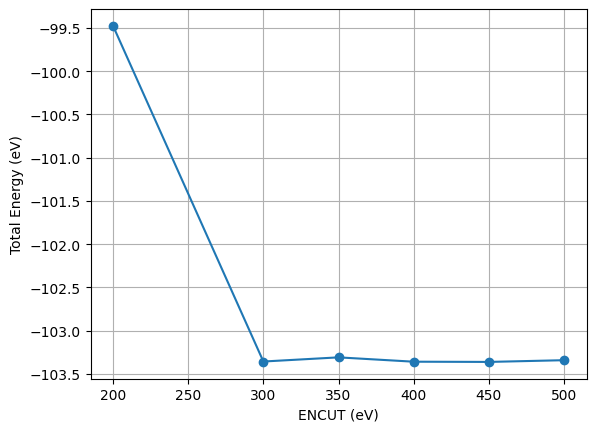

In [8]:
plt.plot(encuts[1:], energies[1:], marker='o')
plt.xlabel('ENCUT (eV)')
plt.ylabel('Total Energy (eV)')
plt.grid()

In [ ]:
import numpy as np

def check_encut_convergence(encut, energies, n_last=3,
                            tol_meV_per_atom=1.0,
                            n_atoms=1):
    """
    Determine whether ENCUT convergence is achieved.

    Parameters
    ----------
    encut : list or array
        ENCUT values (ascending order recommended)
    energies : list or array
        Total energies corresponding to ENCUT values (eV)
    n_last : int
        Number of last points to check for convergence
    tol_meV_per_atom : float
        Convergence threshold in meV/atom
    n_atoms : int
        Number of atoms in the system

    Returns
    -------
    dict with:
        converged (bool)
        max_delta_meV_per_atom (float)
        max_slope_meV_per_atom (float)
    """

    encut = np.array(encut)
    energies = np.array(energies)

    # convert to energy per atom (meV)
    epa = (energies / n_atoms) * 1000  # eV → meV

    if len(epa) < n_last + 1:
        raise ValueError("Not enough data points for convergence test")

    # take last segment
    e_tail = epa[-n_last:]
    x_tail = encut[-n_last:]

    # max energy fluctuation in tail
    max_delta = np.max(e_tail) - np.min(e_tail)

    # approximate slope in tail (linear fit)
    slope = np.polyfit(x_tail, e_tail, 1)[0]

    # convergence criteria
    converged = (
        max_delta < tol_meV_per_atom and
        abs(slope) < tol_meV_per_atom / (x_tail.max() - x_tail.min())
    )

    return {
        "converged": converged,
        "max_delta_meV_per_atom": max_delta,
        "max_slope_meV_per_atom": slope
    }

In [7]:
# kpoints convergence results
subfolders = os.listdir("kpoints_convergence")

kpoints = []
energies = []

# sort the subfolders by kpoints value
subfolders.sort(key=lambda x: int(x.split("_")[1]))

for subfolder in subfolders:
    if subfolder.startswith("kpoints_"):
        kpoints_value = int(subfolder.split("_")[1])
        energy = get_total_energy(f'kpoints_convergence/{subfolder}/OUTCAR')
        print(f'KPOINTS: {kpoints_value}x{kpoints_value}x{kpoints_value}, Total Energy: {energy} eV')
        if energy is not None:
            kpoints.append(kpoints_value)
            energies.append(energy)

KPOINTS: 1x1x1, Total Energy: -101.40023618 eV
KPOINTS: 2x2x2, Total Energy: -104.29912898 eV
KPOINTS: 3x3x3, Total Energy: -102.54864581 eV
KPOINTS: 4x4x4, Total Energy: -103.35043183 eV
KPOINTS: 5x5x5, Total Energy: -103.14843921 eV
KPOINTS: 6x6x6, Total Energy: -103.26907646 eV
KPOINTS: 7x7x7, Total Energy: -103.24416629 eV
KPOINTS: 8x8x8, Total Energy: -103.25985816 eV


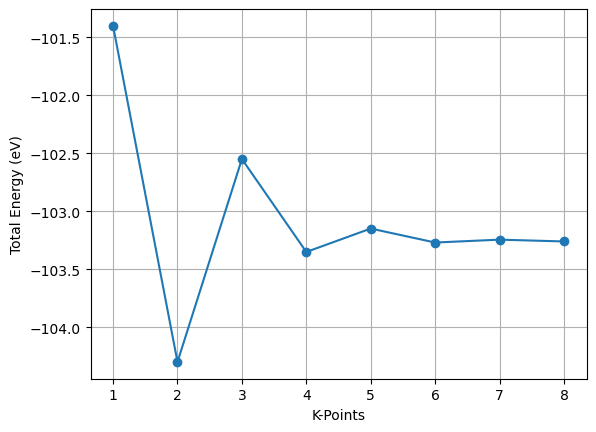

In [8]:
plt.plot(kpoints, energies, marker='o')
plt.xlabel('K-Points')
plt.ylabel('Total Energy (eV)')
plt.grid()